In [30]:
import pandas as pd
import numpy as np
import json
import gzip
import urllib.request
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

In [31]:
# Create function to download data from GH Archive
import io

def download_gh_archive(year, month, day, hour, save_path=None):
    """
    Downloads one hourly archive from GH Archive

    Parameters:
    - year, month, day, hour: date and hour
    - save_path: path to save file
    """
    url = f"https://data.gharchive.org/{year:04d}-{month:02d}-{day:02d}-{hour:02d}.json.gz"
    print(f"Downloading {url}...")

    try:
        # Create request with proper User-Agent header
        req = urllib.request.Request(
            url,
            headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        )
        
        with urllib.request.urlopen(req, timeout=30) as response:
            data = response.read()

        if save_path:
            with open(save_path, 'wb') as f:
                f.write(data)
            print(f"Saved to {save_path} ({len(data) / (1024*1024):.1f} MB)")
            return save_path
        else:
            # Load into memory
            events = []
            with gzip.open(io.BytesIO(data), 'rt', encoding='utf-8') as f:
                for line in f:
                    events.append(json.loads(line))
            return pd.DataFrame(events)

    except Exception as e:
        print(f"Download error: {e}")
        print("Tip: Make sure you have an internet connection and the URL is accessible")
        return None

# Download data for January 1, 2025, hours 12 and 13
print("Downloading GitHub Archive data...")
print("This may take 1-2 minutes...\n")
download_gh_archive(2025, 1, 1, 12, save_path='raw_data/2025-01-01-12.json.gz')
download_gh_archive(2025, 1, 1, 13, save_path='raw_data/2025-01-01-13.json.gz')
print("\nDownload complete!")

This may take 1-2 minutes...

Saved to raw_data/2025-01-01-12.json.gz (72.6 MB)
Saved to raw_data/2025-01-01-13.json.gz (72.0 MB)

Download complete!


In [32]:
# Then load the file
def load_gh_archive(file_path):
    """Load data from local gz file"""
    events = []
    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for line in f:
            events.append(json.loads(line))
    return pd.DataFrame(events)

df = load_gh_archive('raw_data/2025-01-01-12.json.gz')
print(f"Loaded {len(df)} events")

Loaded 223540 events


INITIAL DATA INSPECTION

In [33]:
print(f"Shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset info:")
df.info()

Shape: (223540, 8)

Column names: ['id', 'type', 'actor', 'repo', 'payload', 'public', 'created_at', 'org']

Data types:
id            object
type          object
actor         object
repo          object
payload       object
public          bool
created_at    object
org           object
dtype: object

First 5 rows:
            id       type                                              actor  \
0  45191299330  PushEvent  {'id': 36498599, 'login': 'jayleecn', 'display...   
1  45191299335  PushEvent  {'id': 166895733, 'login': 'swa-runner-app[bot...   
2  45191299336  PushEvent  {'id': 41898282, 'login': 'github-actions[bot]...   
3  45191299337  PushEvent  {'id': 166895733, 'login': 'swa-runner-app[bot...   
4  45191299339  PushEvent  {'id': 157595799, 'login': 'Bogdan4308', 'disp...   

                                                repo  \
0  {'id': 906604116, 'name': 'jayleecn/Economic-C...   
1  {'id': 910779577, 'name': 'static-web-apps-tes...   
2  {'id': 773697313, 'name': 'iow

COLUMN CATEGORIZATION

In [34]:
# Categorize columns
numeric_cols = []
categorical_cols = []
text_cols = []
datetime_cols = []
nested_cols = []

for col in df.columns:
    if col == 'created_at':
        datetime_cols.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        numeric_cols.append(col)
    elif df[col].dtype == 'object':
        # Check types
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else None
        if isinstance(sample, dict):
            nested_cols.append(col)
        elif isinstance(sample, list):
            nested_cols.append(col)
        else:
            categorical_cols.append(col)
    else:
        categorical_cols.append(col)

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")
print(f"Datetime columns: {datetime_cols}")
print(f"Nested (dict/list) columns: {nested_cols}")

Numeric columns: []
Categorical columns: ['id', 'type', 'public']
Datetime columns: ['created_at']
Nested (dict/list) columns: ['actor', 'repo', 'payload', 'org']


Extract key fields from nested columns

In [35]:
if 'actor' in df.columns:
    df['actor_login'] = df['actor'].apply(lambda x: x.get('login') if isinstance(x, dict) else None)
    df['actor_id'] = df['actor'].apply(lambda x: x.get('id') if isinstance(x, dict) else None)

if 'repo' in df.columns:
    df['repo_name'] = df['repo'].apply(lambda x: x.get('name') if isinstance(x, dict) else None)
    df['repo_id'] = df['repo'].apply(lambda x: x.get('id') if isinstance(x, dict) else None)

# contains specific information about the event
if 'payload' in df.columns:
    df['payload_action'] = df['payload'].apply(lambda x: x.get('action') if isinstance(x, dict) else None)

In [36]:
# Payload action analysis
print(f"Unique payload actions: {df['payload_action'].nunique()}")
payload_actions = df['payload_action'].value_counts().head(10)
print(f"Top payload actions:\n{payload_actions}")

Unique payload actions: 7
Top payload actions:
payload_action
started      8628
created      7431
opened       6796
closed       5462
published     838
added         269
reopened       57
Name: count, dtype: int64


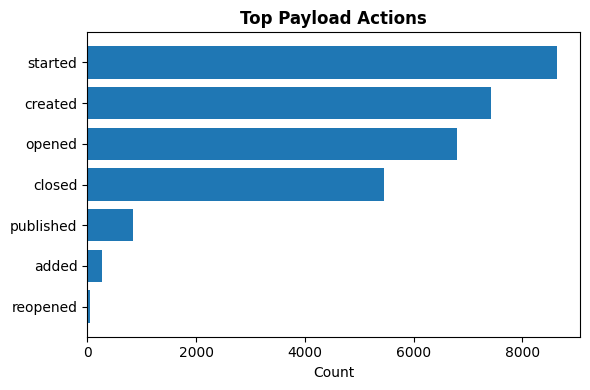

In [37]:
# Single plot - Top Payload Actions
fig, ax = plt.subplots(figsize=(6, 4))

top_actions = df['payload_action'].value_counts().head(8)
ax.barh(range(len(top_actions)), top_actions.values)
ax.set_yticks(range(len(top_actions)))
ax.set_yticklabels(top_actions.index)
ax.set_xlabel('Count')
ax.set_title('Top Payload Actions', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

MISSING VALUES ANALYSIS

In [38]:
missing_df = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_percentage': (df.isnull().sum() / len(df)) * 100,
    'dtype': df.dtypes.values
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_percentage', ascending=False)

print("Missing values summary:")
print(missing_df)

Missing values summary:
                        column  missing_count  missing_percentage   dtype
payload_action  payload_action         194059           86.811756  object
org                        org         188368           84.265903  object


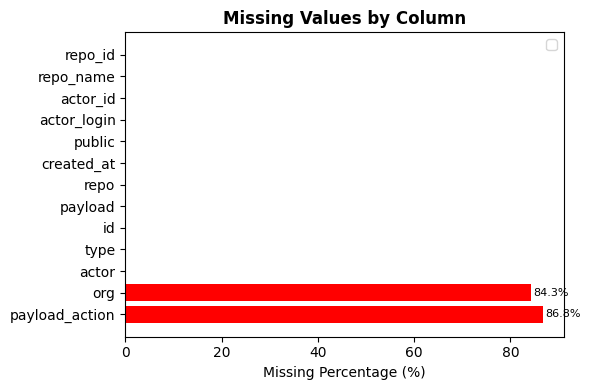

In [39]:
fig, ax2 = plt.subplots(figsize=(6, 4))

# Show ALL columns (including those with 0% missing)
all_columns = pd.DataFrame({
    'column': df.columns,
    'missing_percentage': (df.isnull().sum() / len(df)) * 100
})
all_columns = all_columns.sort_values('missing_percentage', ascending=False)

colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'green' if pct == 0 else 'yellow'
          for pct in all_columns['missing_percentage']]
bars = ax2.barh(all_columns['column'], all_columns['missing_percentage'], color=colors)
ax2.set_xlabel('Missing Percentage (%)')
ax2.set_title('Missing Values by Column', fontweight='bold')
ax2.legend()

# Add percentage labels only for columns with >0% missing
for i, (bar, pct) in enumerate(zip(bars, all_columns['missing_percentage'])):
    if pct > 0:
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

These are structural missing values (not data quality issues) - only special organization-related events and not all events have payload_action, so no critical columns (id, type, created_at, actor, repo) have missing values

DESCRIPTIVE STATISTICS

           actor_id       repo_id
count  2.235400e+05  2.235400e+05
mean   7.532110e+07  6.894221e+08
std    5.603840e+07  2.363619e+08
min    1.770000e+02  3.314000e+03
25%    4.189828e+07  5.165213e+08
50%    4.189828e+07  7.886111e+08
75%    1.151386e+08  8.991548e+08
max    1.934022e+08  9.107949e+08


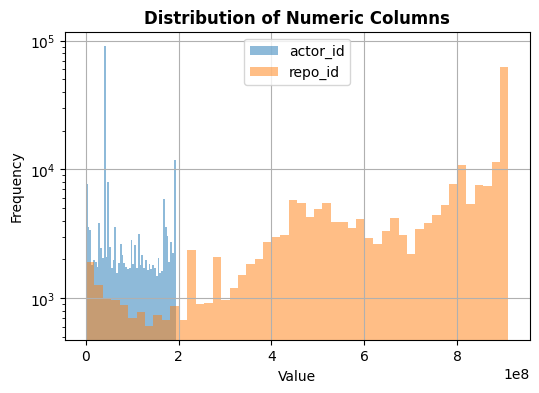

In [40]:
# Statistics for numeric variables
numeric_df = df.select_dtypes(include=[np.number])
if len(numeric_df.columns) > 0:
    print(numeric_df.describe())

# Plot 3: Distribution of numeric columns
fig, ax3 = plt.subplots(figsize=(6, 4))
if len(numeric_df.columns) > 0:
    for col in numeric_df.columns[:2]:  # First 2 numeric columns
        numeric_df[col].hist(bins=50, alpha=0.5, label=col, ax=ax3)
    ax3.set_xlabel('Value')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Distribution of Numeric Columns', fontweight='bold')
    ax3.legend()
    ax3.set_yscale('log')

actor_id and repo_id are just identifiers, not predictive features. They both have wide ranges but this doesn't indicate activity level and they will NOT be used as features for prediction. Also the hour and day of week will be the same for all - we just want to predict the activity of users based on features **regardless of when they are active, so time-based features are irrelevant for this specific task.**



TYPE
Unique values: 15
Top values: {'PushEvent': 168413, 'CreateEvent': 19203, 'PullRequestEvent': 10465, 'WatchEvent': 8628, 'IssueCommentEvent': 4989}
Dominant value covers: 75.3%

PAYLOAD_ACTION
Unique values: 7
Top values: {'started': 8628, 'created': 7431, 'opened': 6796, 'closed': 5462, 'published': 838}
Dominant value covers: 3.9%

ACTOR_LOGIN
Unique values: 37,297
Top values: {'github-actions[bot]': 88114, 'dependabot[bot]': 5818, 'swa-runner-app[bot]': 3393, 'renovate[bot]': 2050, 'frdpzk2': 1758}
Dominant value covers: 39.4%

REPO_NAME
Unique values: 103,217
Top values: {'frdpzk2/ppub': 1758, 'brand22/d3': 1750, 'frdpzk3/ppub': 1106, 'CelestiaNFT/Welcome-NFT': 1043, 'iniadittt/iniadittt': 689}
Dominant value covers: 0.8%


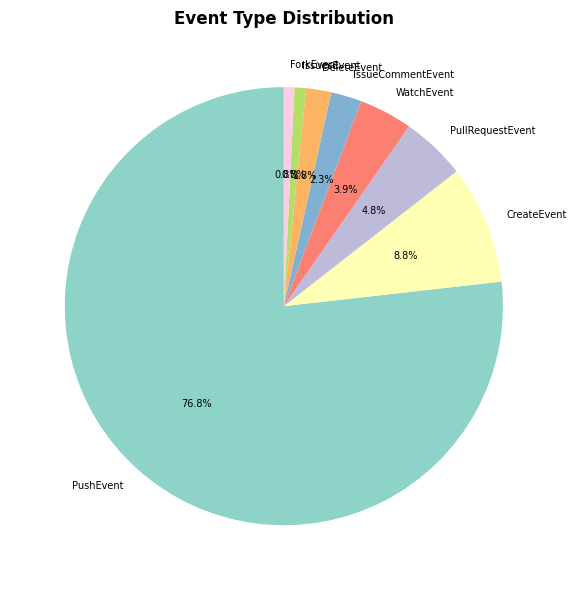

In [41]:
# Statistics for сategorical variables
categorical_cols = ['type', 'payload_action', 'actor_login', 'repo_name']
categorical_analysis = {}

for col in categorical_cols:
    if col in df.columns and df[col].dtype == 'object':
        value_counts = df[col].value_counts()
        categorical_analysis[col] = {
            'unique_count': df[col].nunique(),
            'top_values': value_counts.head(5).to_dict(),
            'dominant_percentage': (value_counts.iloc[0] / len(df) * 100) if len(value_counts) > 0 else 0
        }
        print(f"\n{col.upper()}")
        print(f"Unique values: {categorical_analysis[col]['unique_count']:,}")
        print(f"Top values: {categorical_analysis[col]['top_values']}")
        print(f"Dominant value covers: {categorical_analysis[col]['dominant_percentage']:.1f}%")

# Plot 4: Event type distribution
fig, ax4 = plt.subplots(figsize=(12, 6))
event_types = df['type'].value_counts()
top_events = event_types.head(8)
colors = plt.cm.Set3(range(len(top_events)))
wedges, texts, autotexts = ax4.pie(top_events.values, labels=top_events.index,
                                     autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 7})
ax4.set_title('Event Type Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

EVENT TYPES ANALYSIS

In [42]:
event_types = df['type'].value_counts()
print(f"Total event types: {len(event_types)}")
print(f"\nDistribution:")
print(event_types)

event_percentages = (event_types / len(df) * 100).round(2)
print(f"\nPercentage distribution:")
for event_type, pct in event_percentages.head(10).items():
    print(f"  {event_type}: {pct}%")

# Detailed event characteristics
event_characteristics = {}
for event_type in event_types.head(10).index:
    event_df = df[df['type'] == event_type]

    event_characteristics[event_type] = {
        'count': len(event_df),
        'percentage': (len(event_df) / len(df)) * 100,
        'has_actor': event_df['actor_login'].notna().sum() / len(event_df) * 100,
        'unique_users': event_df['actor_login'].nunique(),
        'unique_repos': event_df['repo_name'].nunique(),
        'avg_events_per_user': len(event_df) / max(event_df['actor_login'].nunique(), 1)
    }

    print(f"\n[{event_type}]")
    print(f"  Count: {event_characteristics[event_type]['count']:,} ({event_characteristics[event_type]['percentage']:.1f}%)")
    print(f"  Unique users: {event_characteristics[event_type]['unique_users']:,}")
    print(f"  Unique repos: {event_characteristics[event_type]['unique_repos']:,}")
    print(f"  Avg events per user: {event_characteristics[event_type]['avg_events_per_user']:.2f}")

Total event types: 15

Distribution:
type
PushEvent                        168413
CreateEvent                       19203
PullRequestEvent                  10465
WatchEvent                         8628
IssueCommentEvent                  4989
DeleteEvent                        4056
IssuesEvent                        1850
ForkEvent                          1712
PullRequestReviewEvent             1678
ReleaseEvent                        838
PullRequestReviewCommentEvent       764
PublicEvent                         421
MemberEvent                         269
GollumEvent                         145
CommitCommentEvent                  109
Name: count, dtype: int64

Percentage distribution:
  PushEvent: 75.34%
  CreateEvent: 8.59%
  PullRequestEvent: 4.68%
  WatchEvent: 3.86%
  IssueCommentEvent: 2.23%
  DeleteEvent: 1.81%
  IssuesEvent: 0.83%
  ForkEvent: 0.77%
  PullRequestReviewEvent: 0.75%
  ReleaseEvent: 0.37%

[PushEvent]
  Count: 168,413 (75.3%)
  Unique users: 25,045
  Unique repos: 

* PushEvent dominates (75.3%) - most common activity on GitHub
* CreateEvent (8.6%) - users creating branches/tags/repos
* PullRequestEvent (4.7%) - active code review culture
* WatchEvent (3.9%) - users starring repositories
* These 4 types represent 92.5% of all activity

TEMPORAL ANALYSIS

In [43]:
if 'created_at' in df.columns:
    df['created_at_dt'] = pd.to_datetime(df['created_at'])
    df['hour'] = df['created_at_dt'].dt.hour
    df['day_of_week'] = df['created_at_dt'].dt.dayofweek
    df['minute'] = df['created_at_dt'].dt.minute

    print(f"Time range: {df['created_at_dt'].min()} - {df['created_at_dt'].max()}")
    print(f"\n[IMPORTANT NOTE] This is ONLY 1 hour of data (12:00-13:00 UTC)")
    print("Temporal patterns cannot be analyzed with single hour!")

    hourly_activity = df.groupby('hour').size()
    print(f"\nPeak activity hour: {hourly_activity.idxmax()}:00 (only hour available)")

    weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily_activity = df.groupby('day_of_week').size()
    print(f"Day of week: {weekdays[daily_activity.idxmax()]} (all data from same day)")

Time range: 2025-01-01 12:00:00+00:00 - 2025-01-01 12:59:59+00:00

[IMPORTANT NOTE] This is ONLY 1 hour of data (12:00-13:00 UTC)
Temporal patterns cannot be analyzed with single hour!

Peak activity hour: 12:00 (only hour available)
Day of week: Wednesday (all data from same day)


TEMPORAL ANALYSIS LIMITATION
* Data is from ONLY 1 hour (12:00-13:00 UTC, Jan 1, 2025)
* Cannot analyze hourly/daily/weekly patterns meaningfully

In [44]:
# Load two hours of data for temporal prediction
df_12 = load_gh_archive('raw_data/2025-01-01-12.json.gz')  # 12:00-13:00 (Features)
df_13 = load_gh_archive('raw_data/2025-01-01-13.json.gz')  # 13:00-14:00 (Target)

print(f"Loaded Hour 12: {len(df_12)} events")
print(f"Loaded Hour 13: {len(df_13)} events")

# Parse nested fields for BOTH dataframes
def parse_nested_fields(df):
    """Extract actor_login and repo_name from nested columns"""
    if 'actor' in df.columns:
        df['actor_login'] = df['actor'].apply(lambda x: x.get('login') if isinstance(x, dict) else None)
    if 'repo' in df.columns:
        df['repo_name'] = df['repo'].apply(lambda x: x.get('name') if isinstance(x, dict) else None)
    return df

df_12 = parse_nested_fields(df_12)
df_13 = parse_nested_fields(df_13)

# Helper function to aggregate user activity for a given hour
def aggregate_user_features(df, hour_label):
    """Aggregate user-level features from event data"""
    aggregated = df.groupby('actor_login').agg({
        'id': 'count',                                      # total events
        'type': lambda x: x.nunique(),                      # event type diversity
        'repo_name': lambda x: x.nunique(),                 # unique repos
    }).rename(columns={
        'id': f'total_events_{hour_label}',
        'type': f'event_type_diversity_{hour_label}',
        'repo_name': f'unique_repos_{hour_label}'
    })
    return aggregated

# Create features from Hour 12
X = aggregate_user_features(df_12, 'h12')
print(f"\nFeatures from Hour 12: {len(X):,} users")

# Create target from Hour 13 (active if > 3 events in next hour)
user_activity_h13 = df_13.groupby('actor_login').agg({
    'id': 'count'
}).rename(columns={'id': 'total_events_h13'})

# Define active users (75th percentile threshold from Hour 13)
active_threshold_h13 = user_activity_h13['total_events_h13'].quantile(0.75)
user_activity_h13['is_active_next_hour'] = (user_activity_h13['total_events_h13'] > active_threshold_h13).astype(int)

# Merge features and target
user_activity = X.join(user_activity_h13[['is_active_next_hour']], how='inner')
user_activity['total_events_h13'] = user_activity_h13['total_events_h13']

print(f"\nUsers with activity in both hours: {len(user_activity):,}")
print(f"Target threshold (75th percentile of Hour 13): {active_threshold_h13:.0f} events")

print(f"\nStatistics for Hour 12 features:")
print(user_activity[[f'total_events_h12', f'event_type_diversity_h12', f'unique_repos_h12']].describe())

print(f"\nTarget distribution (active in next hour):")
print(user_activity['is_active_next_hour'].value_counts())
print(f"Active user percentage in next hour: {user_activity['is_active_next_hour'].mean() * 100:.1f}%")

# Also compute thresholds for descriptive purposes
active_threshold_h12 = user_activity[f'total_events_h12'].quantile(0.75)
very_active_threshold_h12 = user_activity[f'total_events_h12'].quantile(0.9)

print(f"\nActivity thresholds for Hour 12 (descriptive only):")
print(f"  75th percentile: {active_threshold_h12:.0f} events in Hour 12")
print(f"  90th percentile: {very_active_threshold_h12:.0f} events in Hour 12")

# Optional: Create descriptive labels (not for modeling)
user_activity['was_active_h12'] = (user_activity[f'total_events_h12'] > active_threshold_h12).astype(int)

print(f"\nCorrelation between Hour 12 activity and Hour 13 activity:")
print(f"  Users active in H12 who stayed active in H13: ", end="")
active_both = ((user_activity['was_active_h12'] == 1) & (user_activity['is_active_next_hour'] == 1)).sum()
active_h12_count = (user_activity['was_active_h12'] == 1).sum()
if active_h12_count > 0:
    print(f"{active_both / active_h12_count * 100:.1f}%")

Loaded Hour 12: 223540 events
Loaded Hour 13: 197224 events

Features from Hour 12: 37,297 users

Users with activity in both hours: 10,124
Target threshold (75th percentile of Hour 13): 3 events

Statistics for Hour 12 features:
       total_events_h12  event_type_diversity_h12  unique_repos_h12
count      10124.000000              10124.000000      10124.000000
mean          16.226788                  1.357566          7.598084
std          879.506781                  0.800302        588.696728
min            1.000000                  1.000000          1.000000
25%            1.000000                  1.000000          1.000000
50%            2.000000                  1.000000          1.000000
75%            4.000000                  1.000000          1.000000
max        88114.000000                 10.000000      59212.000000

Target distribution (active in next hour):
is_active_next_hour
0    7141
1    2983
Name: count, dtype: int64
Active user percentage in next hour: 29.5%

Acti

We use **Hour 12 (12:00-13:00)** to predict activity in **Hour 13 (13:00-14:00)**. This is a proper predictive setup - features from past, target from future - this approach helps to avoid data leakage

### Features to Use
- total_events - main activity indicator
- event_type_diversity - engagement breadth
- unique_repos - user reach on GitHub

### Features to Exclude
- actor_id, repo_id (just identifiers)
- payload_action, org (over 85% missing)

### Missing Values Handling
- Drop payload_action and org (over 50% missing)
- Fill typical_hour with median value (12:00)

### Normalization
- Random Forest or XGBoost: no normalization needed
- Logistic Regression or SVM: use StandardScaler
- Anyways we make normalisation (it won't hurt but we can avoid data spread)

**Distribution issues detected:**
- total_events: severe skew (1 to 88,114)
- event_type_diversity: moderate skew (1 to 10)
- unique_repos: severe skew (1 to 59,212)

### Class Imbalance
Based on the analysis, inactive users (class 0) significantly outnumber active users (class 1).
- Ratio is 2.3 inactive to 1 active (moderately imbalanced)
- Use class_weight='balanced' in Random Forest
- Evaluate with F1-score and ROC-AUC, not accuracy

**Current distribution:**
- Inactive users (class 0): 7,141 users (70.5%)
- Active users (class 1): 2,983 users (29.5%)

### Derived Features to Create
- events_per_repo = total_events / (unique_repos + 1)
- diversity_score = event_type_diversity / total_events
- log_total_events = log1p(total_events)
-is_bot_suspect equals = total_events greater than 1000

### Data Quality Issues
- Extreme outlier: user with 88k events in 1 hour (likely bot)
- Cap total_events at the 99th percentile (winsorization technique)

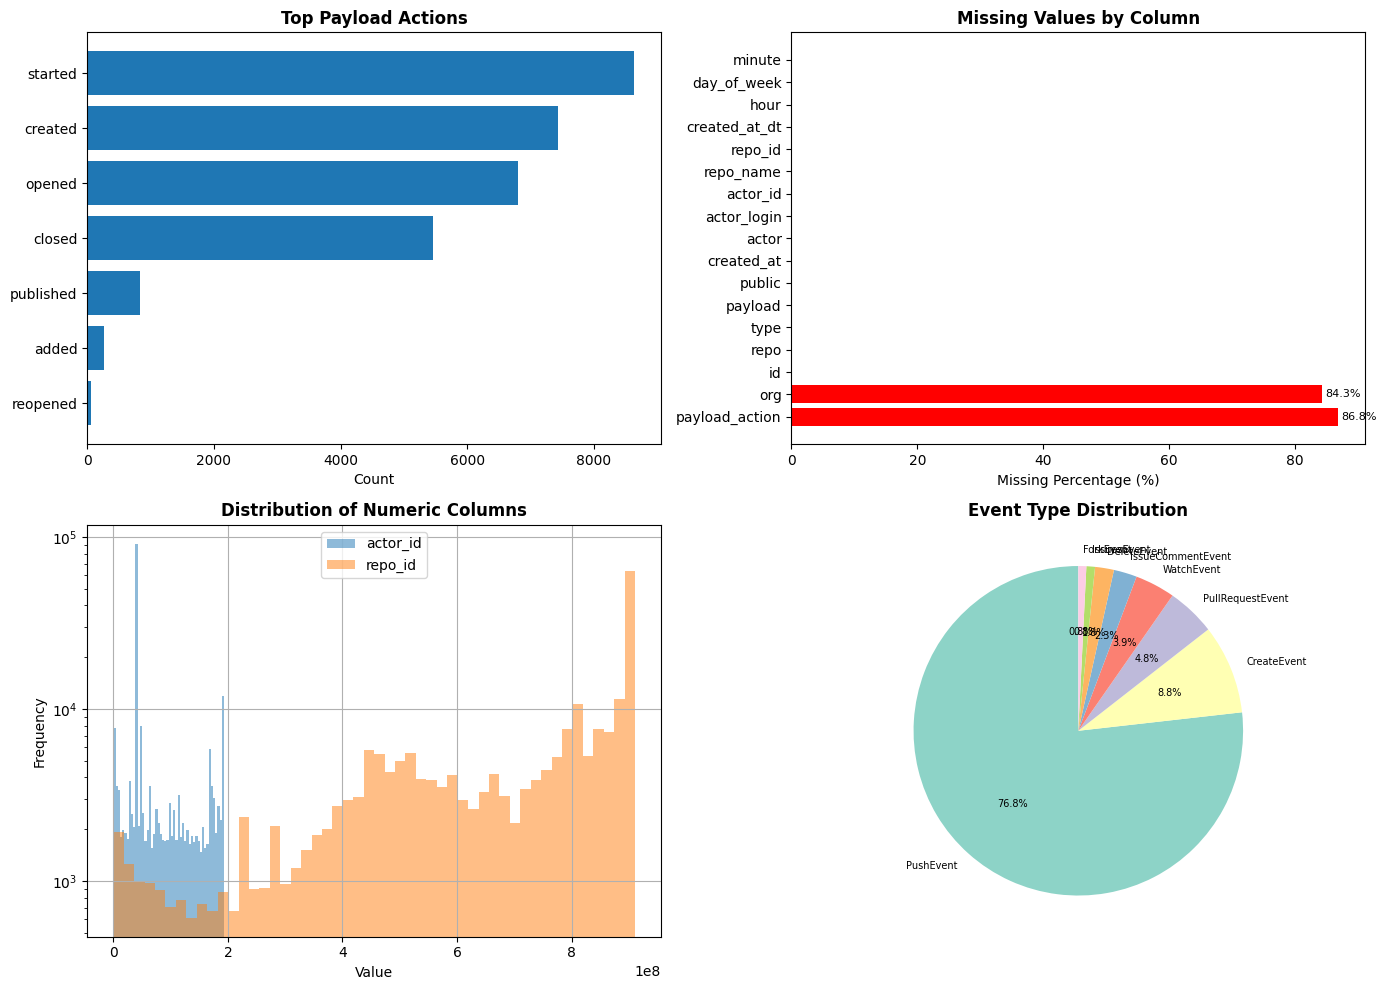

In [45]:
# Create single figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Top Payload Actions (top-left)
top_actions = df['payload_action'].value_counts().head(8)
axes[0, 0].barh(range(len(top_actions)), top_actions.values)
axes[0, 0].set_yticks(range(len(top_actions)))
axes[0, 0].set_yticklabels(top_actions.index)
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Top Payload Actions', fontweight='bold')
axes[0, 0].invert_yaxis()

# Plot 2: Missing Values (top-right)
all_columns = pd.DataFrame({
    'column': df.columns,
    'missing_percentage': (df.isnull().sum() / len(df)) * 100
})
all_columns = all_columns.sort_values('missing_percentage', ascending=False)

colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'green' if pct == 0 else 'yellow'
          for pct in all_columns['missing_percentage']]
bars = axes[0, 1].barh(all_columns['column'], all_columns['missing_percentage'], color=colors)
axes[0, 1].set_xlabel('Missing Percentage (%)')
axes[0, 1].set_title('Missing Values by Column', fontweight='bold')

for i, (bar, pct) in enumerate(zip(bars, all_columns['missing_percentage'])):
    if pct > 0:
        axes[0, 1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                        f'{pct:.1f}%', va='center', fontsize=8)

# Plot 3: Distribution of Numeric Columns (bottom-left)
numeric_df = df.select_dtypes(include=[np.number])
if len(numeric_df.columns) > 0:
    for col in numeric_df.columns[:2]:
        numeric_df[col].hist(bins=50, alpha=0.5, label=col, ax=axes[1, 0])
    axes[1, 0].set_xlabel('Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Numeric Columns', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].set_yscale('log')

# Plot 4: Event Type Distribution (bottom-right)
event_types = df['type'].value_counts()
top_events = event_types.head(8)
colors_pie = plt.cm.Set3(range(len(top_events)))
axes[1, 1].pie(top_events.values, labels=top_events.index,
               autopct='%1.1f%%', colors=colors_pie, startangle=90, textprops={'fontsize': 7})
axes[1, 1].set_title('Event Type Distribution', fontweight='bold')

# Adjust layout and save
plt.tight_layout()
plt.savefig('all_plots.png', dpi=150, bbox_inches='tight')
plt.show()